<a href="https://colab.research.google.com/github/Mrzrm77/NER-with-Spacy-Models/blob/main/NER_with_Spacy_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Raw Dataset and Dataset Reconstruction

In [32]:
import os

directory_name = "dataset"

if not os.path.exists(directory_name):
    os.makedirs(directory_name)
    print(f"Directory '{directory_name}' created successfully.")
else:
    print(f"Directory '{directory_name}' already exist.")

Directory 'dataset' already exist.


In [33]:
import json

file_path = "/content/dataset/sitija_takon_bapa_dataset.txt"
file_path2 = "/content/dataset/abimanyu_rabi_dataset.txt"
file_path3 = "/content/dataset/gatutkaca_rabi_dataset.txt"

# Combine paths into a list for processing
file_paths = [file_path, file_path2, file_path3]

loaded_data_from_txt = []

for current_file_path in file_paths:
    with open(current_file_path, 'r', encoding='utf-8') as f:
        content = f.read()
        # Split by dot and filter out empty strings after stripping whitespace
        segments = [s.strip() for s in content.split('.') if s.strip()]

        for segment in segments:
            loaded_data_from_txt.append({"text": segment, "entities": []}) # Assuming no entities are provided initially

print(f"Data successfully loaded from {file_paths} and save in 'loaded_data_from_txt'.")
print(f"Numbers of entry: {len(loaded_data_from_txt)}")
print("Some first entry:")
for i, entry in enumerate(loaded_data_from_txt):
    if i >= 5:
        break
    print(json.dumps(entry, ensure_ascii=False))

Data successfully loaded from ['/content/dataset/sitija_takon_bapa_dataset.txt', '/content/dataset/abimanyu_rabi_dataset.txt', '/content/dataset/gatutkaca_rabi_dataset.txt'] and save in 'loaded_data_from_txt'.
Numbers of entry: 836
Some first entry:
{"text": "RADEN SITIJA MEMINTA IZIN INGIN BERTEMU AYAHNYA", "entities": []}
{"text": "Di Kahyangan Ekapratala,\nBatara Nagaraja Ekawarna dihadap putrinya, yaitu Batari Pretiwi, serta kedua\ncucunya, yaitu Raden Sitija dan Dewi Sitisundari", "entities": []}
{"text": "Hari itu Batari Pretiwi\nmenyampaikan niat kedua anaknya tersebut yang mohon izin ingin meninggalkan\nkahyangan untuk bertemu ayah mereka di dunia fana", "entities": []}
{"text": "Karena didesak terus-menerus, Batari\nPretiwi akhirnya menceritakan bahwa ayah kandung Raden Sitija dan Dewi\nSitisundari adalah Batara Wisnu dari Kahyangan Utarasagara", "entities": []}
{"text": "Akan tetapi, saat\nini Batara Wisnu sedang tidak berada di kahyangan tersebut, karena sudah\nmenitis dan t

clean text create json format

In [34]:
import re
import string


PUNCT = string.punctuation
PUNCT_REGEX = re.compile(r"[{}]".format(re.escape(PUNCT)))

def clean_and_lowercase_text(text):
    """Removes all punctuation from a string, removes extra spaces, and converts to lowercase."""
    cleaned = PUNCT_REGEX.sub("", text)
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned.lower()

def find_all_occurrences(text, substring):
    """Finds all start-end pairs of a substring in the text."""
    # Use re.escape to handle special characters in the substring if any
    return [(m.start(), m.end()) for m in re.finditer(re.escape(substring), text)]

def preprocess_data_from_txt(input_data):
    output = []

    for data_item in input_data:
        text = data_item["text"]
        entities = data_item["entities"]

        cleaned_text = clean_and_lowercase_text(text)

        new_entities = []
        for start, end, label in entities:
            original_span = text[start:end]
            # Clean and lowercase the original span text as well, to match the cleaned_text format
            cleaned_original_span = clean_and_lowercase_text(original_span)

            # Find new offsets in cleaned_text
            occurrences = find_all_occurrences(cleaned_text, cleaned_original_span)

            if occurrences:
                new_start, new_end = occurrences[0] # Take the first occurrence
                new_entities.append([new_start, new_end, label])
            else:
                # Warning if entity is not found after cleaning
                # This can happen if the original span consists only of punctuation or
                # cleaning changes it so drastically that it can no longer be found.
                # This entity will be skipped.
                print(f"[WARNING] Original span '{original_span}' (after cleaning and lowercasing to '{cleaned_original_span}') not found in cleaned text: '{cleaned_text}'. Entity skipped.")

        output.append({
            "text": cleaned_text,
            "entities": new_entities
        })
    return output

# Run preprocessing on loaded_data_from_txt and save the results to a new variable
preprocessed_data_from_txt = preprocess_data_from_txt(loaded_data_from_txt)

print("=== PREPROCESSING FROM TXT COMPLETE ===")
print(f"Preprocessed data stored in variable 'preprocessed_data_from_txt'.")
print(f"Number of entries: {len(preprocessed_data_from_txt)}")
print("Some first entries:")
for i, entry in enumerate(preprocessed_data_from_txt):
    if i >= 5: # Print only the first 5 entries
        break
    print(json.dumps(entry, ensure_ascii=False))

=== PREPROCESSING FROM TXT COMPLETE ===
Preprocessed data stored in variable 'preprocessed_data_from_txt'.
Number of entries: 836
Some first entries:
{"text": "raden sitija meminta izin ingin bertemu ayahnya", "entities": []}
{"text": "di kahyangan ekapratala batara nagaraja ekawarna dihadap putrinya yaitu batari pretiwi serta kedua cucunya yaitu raden sitija dan dewi sitisundari", "entities": []}
{"text": "hari itu batari pretiwi menyampaikan niat kedua anaknya tersebut yang mohon izin ingin meninggalkan kahyangan untuk bertemu ayah mereka di dunia fana", "entities": []}
{"text": "karena didesak terusmenerus batari pretiwi akhirnya menceritakan bahwa ayah kandung raden sitija dan dewi sitisundari adalah batara wisnu dari kahyangan utarasagara", "entities": []}
{"text": "akan tetapi saat ini batara wisnu sedang tidak berada di kahyangan tersebut karena sudah menitis dan terlahir sebagai manusia bernama prabu kresna di kerajaan dwarawati", "entities": []}


create label entities

In [35]:
entities = [
    # ===== CHARACTERS (Humans/Giants/Creatures) =====

    ## Main and Recurring Characters
    ("Raden Sitija", "TOKOH"),
    ("Dewi Sitisundari", "TOKOH"),
    ("Prabu Kresna", "TOKOH"),
    ("Prabu Kresna Wasudewa", "TOKOH"),
    ("Raden Gatutkaca", "TOKOH"),
    ("Raden Arjuna", "TOKOH"),
    ("Arya Wrekodara", "TOKOH"),
    ("Raden Abimanyu", "TOKOH"),
    ("Endang Pregiwa", "TOKOH"),
    ("Endang Pregiwati", "TOKOH"),
    ("Prabu Duryudana", "TOKOH"),
    ("Raden Lesmana Mandrakumara", "TOKOH"),
    ("Raden Lesmana", "TOKOH"),
    ("Patih Sangkuni", "TOKOH"),
    ("Arya Setyaki", "TOKOH"),
    ("Dewi Sumbadra", "TOKOH"),

    ## Dwarawati Family's
    ("Raden Samba Wisnubrata", "TOKOH"),
    ("Raden Samba", "TOKOH"),
    ("Patih Udawa", "TOKOH"),
    ("Dewi Rukmini", "TOKOH"),

    ## The Kurawa's
    ("Arya Dursasana", "TOKOH"),
    ("Raden Kartawarma", "TOKOH"),
    ("Raden Durmagati", "TOKOH"),
    ("Raden Surtayu", "TOKOH"),
    ("Raden Citraksa", "TOKOH"),
    ("Raden Citraksi", "TOKOH"),
    ("Raden Durmuka", "TOKOH"),
    ("Raden Durjaya", "TOKOH"),
    ("Adipati Jayadrata", "TOKOH"),
    ("Bambang Aswatama", "TOKOH"),
    ("Raden Srutayu", "TOKOH"),

    ## The Pandawa Family and Allies
    ("Prabu Puntadewa", "TOKOH"),
    ("Dewi Drupadi", "TOKOH"),
    ("Raden Nakula", "TOKOH"),
    ("Raden Sadewa", "TOKOH"),
    ("Prabustri Arimbi", "TOKOH"),
    ("Prabu Baladewa", "TOKOH"),
    ("Wasi Jaladara", "TOKOH"),

    ## Hastina Family's
    ("Dewi Banuwati", "TOKOH"),
    ("Adipati Dretarastra", "TOKOH"),
    ("Prabu Pandu", "TOKOH"),

    ## The Teachers and Sages
    ("Danghyang Druna", "TOKOH"),
    ("Resi Sidiwacana", "TOKOH"),
    ("Resi Anoman", "TOKOH"),
    ("Resiwara Bisma", "TOKOH"),
    ("Bagawan Abyasa", "TOKOH"),

    ## Characters from the Sitija Story
    ("Prabu Narakasura", "TOKOH"),
    ("Kyai Togog", "TOKOH"),
    ("Bilung", "TOKOH"),
    ("Ditya Yayahgriwa", "TOKOH"),
    ("Ditya Ancakogra", "TOKOH"),
    ("Ditya Mahodara", "TOKOH"),
    ("Ditya Amisunda", "TOKOH"),
    ("Paksi Wilmuna", "TOKOH"),
    ("Paksi Wildata", "TOKOH"),
    ("Prabu Bomantara", "TOKOH"),
    ("Patih Pancadnyana", "TOKOH"),
    ("Prabu Boma Narakasura", "TOKOH"),
    ("Prabu Boma", "TOKOH"),
    ("Patih Sekiputantra", "TOKOH"),
    ("Prabu Kalapracona", "TOKOH"),
    ("Prabu Kuntiboja", "TOKOH"),

    ## Characters from the story of Abimanyu Rabi
    ("Patih Surata", "TOKOH"),
    ("Patih Sucitra", "TOKOH"),
    ("Endang Manuhara", "TOKOH"),
    ("Cantrik Janaloka", "TOKOH"),
    ("Dewi Erawati", "TOKOH"),
    ("Raden Kartapiyoga", "TOKOH"),
    ("Prabu Salya", "TOKOH"),
    ("Endang Wardiningsih", "TOKOH"),
    ("Nini Mirahdinebak", "TOKOH"),

    ## Characters from the Gatutkaca Rabi Story
    ("Adipati Karna", "TOKOH"),
    ("Prabu Tremboko", "TOKOH"),

    ## The Panakawan's
    ("Kyai Semar", "TOKOH"),
    ("Nala Gareng", "TOKOH"),
    ("Petruk", "TOKOH"),
    ("Bagong", "TOKOH"),

    # ===== GODS (Gods/Goddesses) =====
    ("Batara Nagaraja Ekawarna", "DEWA"),
    ("Batara Ekawarna", "DEWA"),
    ("Batari Pretiwi", "DEWA"),
    ("Batara Wisnu", "DEWA"),
    ("Batara Narada", "DEWA"),
    ("Batara Indra", "DEWA"),
    ("Batara Aswan", "DEWA"),
    ("Batara Aswin", "DEWA"),

    # ===== PLACE (Kingdom/Heaven/Location) =====

    ## Heaven
    ("Kahyangan Ekapratala", "TEMPAT"),
    ("Ekapratala", "TEMPAT"),
    ("Kahyangan Utarasagara", "TEMPAT"),
    ("Utarasagara", "TEMPAT"),
    ("Kahyangan Suralaya", "TEMPAT"),
    ("Suralaya", "TEMPAT"),

    ## Main Government
    ("Kerajaan Dwarawati", "TEMPAT"),
    ("Dwarawati", "TEMPAT"),
    ("Kerajaan Hastina", "TEMPAT"),
    ("Hastina", "TEMPAT"),
    ("Kerajaan Amarta", "TEMPAT"),
    ("Amarta", "TEMPAT"),
    ("Kerajaan Mandura", "TEMPAT"),
    ("Mandura", "TEMPAT"),
    ("Kerajaan Pringgadani", "TEMPAT"),
    ("Pringgadani", "TEMPAT"),

    ## Other Kingdom
    ("Kerajaan Prajatisa", "TEMPAT"),
    ("Prajatisa", "TEMPAT"),
    ("Kerajaan Surateleng", "TEMPAT"),
    ("Surateleng", "TEMPAT"),
    ("Kerajaan Surateleng-Prajatisa", "TEMPAT"),
    ("Surateleng-Prajatisa", "TEMPAT"),
    ("Kerajaan Trajutresna", "TEMPAT"),
    ("Trajutresna", "TEMPAT"),
    ("Dwarawatiprawa", "TEMPAT"),
    ("Dwarakawestri", "TEMPAT"),
    ("Kerajaan Kumbina", "TEMPAT"),
    ("Kumbina", "TEMPAT"),

    ## Chivalry
    ("Kesatrian Paranggaruda", "TEMPAT"),
    ("Paranggaruda", "TEMPAT"),
    ("Kesatrian Swalabumi", "TEMPAT"),
    ("Swalabumi", "TEMPAT"),
    ("Kesatrian Madukara", "TEMPAT"),
    ("Madukara", "TEMPAT"),
    ("Kesatrian Jodipati", "TEMPAT"),
    ("Jodipati", "TEMPAT"),

    ## Padepokan
    ("Padepokan Andongsumawi", "TEMPAT"),
    ("Andongsumawi", "TEMPAT"),
    ("Padepokan Sokalima", "TEMPAT"),
    ("Sokalima", "TEMPAT"),
    ("Padepokan Kendalisada", "TEMPAT"),
    ("Kendalisada", "TEMPAT"),

    ## Special Locations
    ("Widarakandang", "TEMPAT"),
    ("Kawah Candradimuka", "TEMPAT"),
    ("Gunung Jamurdipa", "TEMPAT"),
    ("Taman Maduganda", "TEMPAT"),

    ## Other Places
    ("Awangga", "TEMPAT"),
    ("Plasajenar", "TEMPAT"),
    ("Tirtatinalang", "TEMPAT"),

    # ===== HEIRLOOM (Magical Object/Weapon) =====
    ("Cangkok Wijayamulya", "PUSAKA"),
    ("Kembang Wijayakusuma", "PUSAKA"),
    ("Senjata Cakra", "PUSAKA"),
    ("Keris Kalanadah", "PUSAKA"),
    ("Gada Rujakpolo", "PUSAKA"),
    ("Keris Pulanggeni", "PUSAKA"),
    ("Kotang Antrakusuma", "PUSAKA"),
]
grouped_entities = {}
cleaned_all_entities = []

for entity_name, label in entities:
    cleaned_entity_name = clean_and_lowercase_text(entity_name)
    cleaned_all_entities.append(cleaned_entity_name)

    if label not in grouped_entities:
        grouped_entities[label] = []
    grouped_entities[label].append(cleaned_entity_name)

# Sort the entities within each group by length in descending order
for label in grouped_entities:
    grouped_entities[label] = sorted(grouped_entities[label], key=len, reverse=True)

print("=== ENTITY PREPARATION COMPLETE ===")
print(f"Total cleaned entities: {len(cleaned_all_entities)}")
print("Grouped Entities (sorted by length within each category):")
for label, ents in grouped_entities.items():
    print(f"  {label}: {ents[:5]}... (showing first 5, total {len(ents)})")


=== ENTITY PREPARATION COMPLETE ===
Total cleaned entities: 141
Grouped Entities (sorted by length within each category):
  TOKOH: ['raden lesmana mandrakumara', 'raden samba wisnubrata', 'prabu kresna wasudewa', 'prabu boma narakasura', 'adipati dretarastra']... (showing first 5, total 77)
  DEWA: ['batara nagaraja ekawarna', 'batara ekawarna', 'batari pretiwi', 'batara narada', 'batara wisnu']... (showing first 5, total 8)
  TEMPAT: ['kerajaan suratelengprajatisa', 'kesatrian paranggaruda', 'padepokan andongsumawi', 'kahyangan utarasagara', 'padepokan kendalisada']... (showing first 5, total 49)
  PUSAKA: ['kembang wijayakusuma', 'cangkok wijayamulya', 'kotang antrakusuma', 'keris pulanggeni', 'keris kalanadah']... (showing first 5, total 7)


In [36]:
final_dataset = []

for data_item in preprocessed_data_from_txt:
    text = data_item["text"]
    extracted_entities = []

    # Track used spans to prevent overlaps
    # Store spans as (start, end) tuples
    used_spans = []

    # Iterate through grouped_entities. The entities within each label are already sorted by length (longest first)
    for label, entities_list in grouped_entities.items():
        for entity_name in entities_list:
            # Use re.finditer to find all non-overlapping occurrences of the entity_name
            # re.escape is used to treat entity_name as a literal string, not a regex pattern
            for match in re.finditer(re.escape(entity_name), text):
                start, end = match.start(), match.end()

                # Check for overlaps with already extracted entities
                is_overlapping = False
                for us_start, us_end in used_spans:
                    # Check if the new entity overlaps with any already captured span
                    # An overlap exists if the new span starts before the existing one ends
                    # AND the new span ends after the existing one starts
                    if max(start, us_start) < min(end, us_end):
                        is_overlapping = True
                        break

                if not is_overlapping:
                    extracted_entities.append([start, end, label])
                    used_spans.append((start, end)) # Add this span to our used list

    # Sort extracted_entities by their start offset for consistent output
    extracted_entities.sort(key=lambda x: x[0])

    final_dataset.append({
        "text": text,
        "entities": extracted_entities
    })

print("Entity extraction complete. First 5 entries of final_dataset:")
for i, entry in enumerate(final_dataset):
    if i >= 5:
        break
    print(json.dumps(entry, ensure_ascii=False, indent=2))

Entity extraction complete. First 5 entries of final_dataset:
{
  "text": "raden sitija meminta izin ingin bertemu ayahnya",
  "entities": [
    [
      0,
      12,
      "TOKOH"
    ]
  ]
}
{
  "text": "di kahyangan ekapratala batara nagaraja ekawarna dihadap putrinya yaitu batari pretiwi serta kedua cucunya yaitu raden sitija dan dewi sitisundari",
  "entities": [
    [
      3,
      23,
      "TEMPAT"
    ],
    [
      24,
      48,
      "DEWA"
    ],
    [
      72,
      86,
      "DEWA"
    ],
    [
      113,
      125,
      "TOKOH"
    ],
    [
      130,
      146,
      "TOKOH"
    ]
  ]
}
{
  "text": "hari itu batari pretiwi menyampaikan niat kedua anaknya tersebut yang mohon izin ingin meninggalkan kahyangan untuk bertemu ayah mereka di dunia fana",
  "entities": [
    [
      9,
      23,
      "DEWA"
    ]
  ]
}
{
  "text": "karena didesak terusmenerus batari pretiwi akhirnya menceritakan bahwa ayah kandung raden sitija dan dewi sitisundari adalah batara wisnu dari k

check format dataset

In [37]:
import json
import spacy
from spacy.training import offsets_to_biluo_tags

# -------------------------------
# 1. Use existing variable
# -------------------------------
data = final_dataset

print(f"Total data loaded from variable: {len(data)}")

# -------------------------------
# 2. Load blank model to check offsets
# -------------------------------
nlp = spacy.blank("xx")  # Universal tokenizer (safer for mixed languages)

# -------------------------------
# 3. Check offsets per line
# -------------------------------
errors = []

for i, item in enumerate(data):
    text = item["text"]
    entities = item["entities"]

    doc = nlp(text)

    try:
        tags = offsets_to_biluo_tags(doc, entities)
    except Exception as e:
        errors.append({
            "line": i + 1,
            "text": text,
            "entities": entities,
            "error": str(e)
        })
        continue

    # If there is a '-' sign, it means the offset is not aligned
    if "-" in tags:
        errors.append({
            "line": i + 1,
            "text": text,
            "entities": entities,
            "biluo_tags": tags
        })

# -------------------------------
# 4. Display results
# -------------------------------
if errors:
    print("\nFound misaligned entities:\n")
    for err in errors:
        print("====================================================")
        print(f"Line   : {err['line']}")
        print(f"Text   : {err['text']}")
        print(f"Entities: {err['entities']}")
        if "biluo_tags" in err:
            print(f"BILUO  : {err['biluo_tags']}")
        if "error" in err:
            print(f"ERROR  : {err['error']}")
else:
    print("All entity offsets are ALIGNED! No issues found.")

Total data loaded from variable: 836
All entity offsets are ALIGNED! No issues found.


Split dataset 80,10,10

In [38]:
import random
random.shuffle(final_dataset)

total_len = len(final_dataset)
train_split = int(total_len * 0.8)
val_split = int(total_len * 0.1)

train_data = final_dataset[:train_split]
val_data = final_dataset[train_split : train_split + val_split]
test_data = final_dataset[train_split + val_split:]

len(train_data), len(val_data), len(test_data)

(668, 83, 85)

# Spacy Model

In [39]:
import spacy
from spacy.tokens import DocBin

nlp = spacy.blank("id")

if "ner" not in nlp.pipe_names:
    ner = nlp.add_pipe("ner")
else:
    ner = nlp.get_pipe("ner")

labels = ["TOKOH", "DEWA", "TEMPAT", "PUSAKA"]

for label in labels:
    ner.add_label(label)

In [40]:
from spacy.training import Example

def convert_to_examples(data, nlp_model):
    examples = []
    for item in data:
        doc = nlp_model.make_doc(item["text"])
        ents = []
        for start, end, label in item["entities"]:
            ents.append(doc.char_span(start, end, label=label))
        example = Example.from_dict(doc, {"entities": item["entities"]})
        examples.append(example)
    return examples

train_examples_id = convert_to_examples(train_data, nlp)
val_examples_id = convert_to_examples(val_data, nlp)
test_examples_id = convert_to_examples(test_data, nlp)


In [41]:
import spacy
from spacy.training.example import Example
from spacy.util import minibatch

optimizer = nlp.initialize()
n_iter = 20

loss_history_id = []

for epoch in range(n_iter):
    random.shuffle(train_examples_id)
    losses = {}

    batches = minibatch(train_examples_id, size=8)
    for batch in batches:
        nlp.update(
            batch,
            sgd=optimizer,
            drop=0.25,
            losses=losses
        )

    loss_history_id.append(losses["ner"])
    print(f"Epoch {epoch+1}/{n_iter} - Loss: {losses['ner']:.4f}")


Epoch 1/20 - Loss: 2113.1213
Epoch 2/20 - Loss: 321.7448
Epoch 3/20 - Loss: 171.1881
Epoch 4/20 - Loss: 98.1139
Epoch 5/20 - Loss: 60.4611
Epoch 6/20 - Loss: 40.1040
Epoch 7/20 - Loss: 33.1329
Epoch 8/20 - Loss: 29.0153
Epoch 9/20 - Loss: 19.8049
Epoch 10/20 - Loss: 18.0191
Epoch 11/20 - Loss: 12.8608
Epoch 12/20 - Loss: 20.1717
Epoch 13/20 - Loss: 8.0461
Epoch 14/20 - Loss: 22.3104
Epoch 15/20 - Loss: 11.1212
Epoch 16/20 - Loss: 11.2332
Epoch 17/20 - Loss: 5.2702
Epoch 18/20 - Loss: 4.6672
Epoch 19/20 - Loss: 0.5007
Epoch 20/20 - Loss: 9.4480


# Evaluate model spacy id

In [42]:
from spacy.scorer import Scorer

def evaluate_spacy(nlp_model, examples):
    scorer = Scorer()
    example_list = []

    for ex in examples:
        pred = nlp_model(ex.text)
        example_list.append(Example(pred, ex.reference))

    return scorer.score(example_list)

scores = evaluate_spacy(nlp, test_examples_id)

print("=== Entity Recognition Evaluation (ID Model) ===")
print(f"Exact Match Precision: {scores['ents_p']:.4f}")
print(f"Exact Match Recall:    {scores['ents_r']:.4f}")
print(f"Exact Match F1-score:  {scores['ents_f']:.4f}")

# Calculate Macro F1
macro_f1_sum = 0
num_entity_types = len(scores['ents_per_type'])
if num_entity_types > 0:
    for entity_type_scores in scores['ents_per_type'].values():
        macro_f1_sum += entity_type_scores['f']
    macro_f1 = macro_f1_sum / num_entity_types
else:
    macro_f1 = 0.0
print(f"Macro F1-score:        {macro_f1:.4f}")

# Micro F1 for entities is typically the overall F1 (ents_f)
print(f"Micro F1-score:        {scores['ents_f']:.4f}")

print("\nDetailed scores per entity type:")
for label, metrics in scores['ents_per_type'].items():
    print(f"  {label}: P={metrics['p']:.4f}, R={metrics['r']:.4f}, F={metrics['f']:.4f}")


=== Entity Recognition Evaluation (ID Model) ===
Exact Match Precision: 1.0000
Exact Match Recall:    0.9868
Exact Match F1-score:  0.9933
Macro F1-score:        0.9821
Micro F1-score:        0.9933

Detailed scores per entity type:
  TOKOH: P=1.0000, R=1.0000, F=1.0000
  TEMPAT: P=1.0000, R=0.8667, F=0.9286
  DEWA: P=1.0000, R=1.0000, F=1.0000
  PUSAKA: P=1.0000, R=1.0000, F=1.0000


In [43]:
print("ID Model Example Prediction:")
print(test_examples_id[50].text)
print(nlp(test_examples_id[50].text).ents)


ID Model Example Prediction:
jika mereka berdua tidak sampai melapor maka raden arjuna tidak akan mengetahui persyaratan yang diajukan prabu baladewa
(raden arjuna, prabu baladewa)


In [44]:
from sklearn.metrics import classification_report
from spacy.training import offsets_to_biluo_tags

y_true_biluo_tags = []
y_pred_biluo_tags = []

for ex in val_examples_id:
    # Create a Doc object to ensure consistent tokenization for both gold and predicted
    # We use nlp.make_doc to tokenize the raw text, which matches how the model would tokenize it.
    doc = nlp.make_doc(ex.text)

    # Get gold entities in (start_char, end_char, label) format from the reference Doc
    gold_entity_offsets = [(ent.start_char, ent.end_char, ent.label_) for ent in ex.reference.ents]

    # Get predicted entities in (start_char, end_char, label) format from the model's prediction
    pred_doc = nlp(ex.text)
    pred_entity_offsets = [(ent.start_char, ent.end_char, ent.label_) for ent in pred_doc.ents]

    # Convert character offsets to token-level BILUO tags
    # This ensures that both lists will have a tag for each token, maintaining equal length.
    try:
        gold_biluo_tags = offsets_to_biluo_tags(doc, gold_entity_offsets)
        pred_biluo_tags = offsets_to_biluo_tags(doc, pred_entity_offsets)
    except Exception as e:
        # This catch is for robustness, but based on prior checks, offsets should be aligned.
        print(f"Warning: Error generating BILUO tags for text: {ex.text}. Error: {e}. Skipping this example.")
        continue

    y_true_biluo_tags.extend(gold_biluo_tags)
    y_pred_biluo_tags.extend(pred_biluo_tags)

# Filter out 'O' (Outside) tags if you only want to report on actual entities,
# but for a comprehensive report, it's better to include them.
# You might also want to filter for 'B-', 'I-', 'L-', 'U-' tags to report per-entity type.
# For a general classification report, including 'O' is fine.
print("=== Classification Report (ID Model) ===")
print(classification_report(y_true_biluo_tags, y_pred_biluo_tags, zero_division=0))


=== Classification Report (ID Model) ===
              precision    recall  f1-score   support

      B-DEWA       1.00      1.00      1.00         2
    B-TEMPAT       0.94      1.00      0.97        16
     B-TOKOH       1.00      0.99      1.00       123
     I-TOKOH       1.00      1.00      1.00         5
      L-DEWA       1.00      1.00      1.00         2
    L-TEMPAT       0.94      1.00      0.97        16
     L-TOKOH       1.00      0.99      1.00       123
           O       1.00      1.00      1.00       746
    U-TEMPAT       1.00      1.00      1.00         2

    accuracy                           1.00      1035
   macro avg       0.99      1.00      0.99      1035
weighted avg       1.00      1.00      1.00      1035



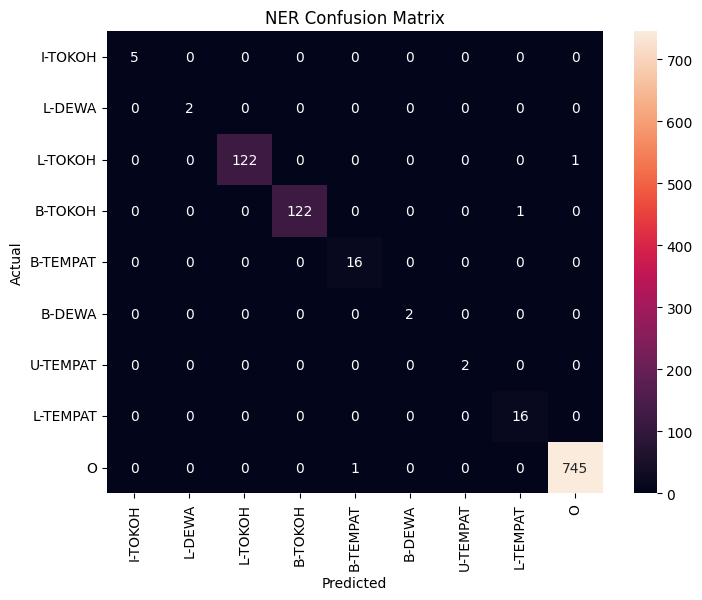

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use the BILUO tags which are guaranteed to have consistent lengths
labels_set = list(set(y_true_biluo_tags + y_pred_biluo_tags))
cm = confusion_matrix(y_true_biluo_tags, y_pred_biluo_tags, labels=labels_set)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=labels_set, yticklabels=labels_set)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("NER Confusion Matrix")
plt.show()


# Model Spacy multilingual

In [46]:
!python -m spacy download xx_ent_wiki_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 83.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('xx_ent_wiki_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [47]:
import spacy
from spacy.tokens import DocBin

nlp_multi = spacy.load("xx_ent_wiki_sm")

if "ner" not in nlp_multi.pipe_names:
    ner = nlp_multi.add_pipe("ner")
else:
    ner = nlp_multi.get_pipe("ner")

labels = ["TOKOH", "DEWA", "TEMPAT", "PUSAKA"]

for label in labels:
    ner.add_label(label)

In [48]:
from spacy.training import Example

def convert_to_examples(data, nlp_model):
    examples = []
    for item in data:
        doc = nlp_model.make_doc(item["text"])
        ents = []
        for start, end, label in item["entities"]:
            ents.append(doc.char_span(start, end, label=label))
        example = Example.from_dict(doc, {"entities": item["entities"]})
        examples.append(example)
    return examples

train_examples_multi = convert_to_examples(train_data, nlp_multi)
val_examples_multi = convert_to_examples(val_data, nlp_multi)
test_examples_multi = convert_to_examples(test_data, nlp_multi)


In [49]:
import spacy
from spacy.training.example import Example
from spacy.util import minibatch

optimizer = nlp_multi.initialize()
n_iter = 20

loss_history_multi = []

for epoch in range(n_iter):
    random.shuffle(train_examples_multi)
    losses = {}

    batches = minibatch(train_examples_multi, size=8)
    for batch in batches:
        nlp_multi.update(
            batch,
            sgd=optimizer,
            drop=0.25,
            losses=losses
        )

    loss_history_multi.append(losses["ner"])
    print(f"Epoch {epoch+1}/{n_iter} - Loss: {losses['ner']:.4f}")


Epoch 1/20 - Loss: 2690.6672
Epoch 2/20 - Loss: 317.7037
Epoch 3/20 - Loss: 180.5009
Epoch 4/20 - Loss: 93.0205
Epoch 5/20 - Loss: 61.6239
Epoch 6/20 - Loss: 44.0533
Epoch 7/20 - Loss: 19.9515
Epoch 8/20 - Loss: 22.9296
Epoch 9/20 - Loss: 14.0879
Epoch 10/20 - Loss: 7.5797
Epoch 11/20 - Loss: 15.6133
Epoch 12/20 - Loss: 8.0448
Epoch 13/20 - Loss: 4.3926
Epoch 14/20 - Loss: 7.2307
Epoch 15/20 - Loss: 12.4446
Epoch 16/20 - Loss: 3.6814
Epoch 17/20 - Loss: 3.9439
Epoch 18/20 - Loss: 21.9188
Epoch 19/20 - Loss: 10.8443
Epoch 20/20 - Loss: 5.9595


# Evaluate Model Spacy Multilingual

In [50]:
from spacy.scorer import Scorer

def evaluate_spacy(nlp_model, examples):
    scorer = Scorer()
    example_list = []

    for ex in examples:
        pred = nlp_model(ex.text)
        example_list.append(Example(pred, ex.reference))

    return scorer.score(example_list)

scores = evaluate_spacy(nlp_multi, test_examples_multi)

print("=== Entity Recognition Evaluation (Multilingual Model) ===")
print(f"Exact Match Precision: {scores['ents_p']:.4f}")
print(f"Exact Match Recall:    {scores['ents_r']:.4f}")
print(f"Exact Match F1-score:  {scores['ents_f']:.4f}")

# Calculate Macro F1
macro_f1_sum = 0
num_entity_types = len(scores['ents_per_type'])
if num_entity_types > 0:
    for entity_type_scores in scores['ents_per_type'].values():
        macro_f1_sum += entity_type_scores['f']
    macro_f1 = macro_f1_sum / num_entity_types
else:
    macro_f1 = 0.0
print(f"Macro F1-score:        {macro_f1:.4f}")

# Micro F1 for entities is typically the overall F1 (ents_f)
print(f"Micro F1-score:        {scores['ents_f']:.4f}")

print("\nDetailed scores per entity type:")
for label, metrics in scores['ents_per_type'].items():
    print(f"  {label}: P={metrics['p']:.4f}, R={metrics['r']:.4f}, F={metrics['f']:.4f}")


=== Entity Recognition Evaluation (Multilingual Model) ===
Exact Match Precision: 1.0000
Exact Match Recall:    0.9868
Exact Match F1-score:  0.9933
Macro F1-score:        0.9821
Micro F1-score:        0.9933

Detailed scores per entity type:
  TOKOH: P=1.0000, R=1.0000, F=1.0000
  TEMPAT: P=1.0000, R=0.8667, F=0.9286
  DEWA: P=1.0000, R=1.0000, F=1.0000
  PUSAKA: P=1.0000, R=1.0000, F=1.0000


In [51]:
print("Multilingual Model Example Prediction:")
print(test_examples_multi[50].text)
print(nlp_multi(test_examples_multi[50].text).ents)


Multilingual Model Example Prediction:
jika mereka berdua tidak sampai melapor maka raden arjuna tidak akan mengetahui persyaratan yang diajukan prabu baladewa
(raden arjuna, prabu baladewa)


In [52]:
from sklearn.metrics import classification_report
from spacy.training import offsets_to_biluo_tags

y_true_biluo_tags_multi = []
y_pred_biluo_tags_multi = []

for ex in val_examples_multi:
    # Create a Doc object to ensure consistent tokenization for both gold and predicted
    # We use nlp_multi.make_doc to tokenize the raw text, which matches how the model would tokenize it.
    doc = nlp_multi.make_doc(ex.text)

    # Get gold entities in (start_char, end_char, label) format from the reference Doc
    gold_entity_offsets = [(ent.start_char, ent.end_char, ent.label_) for ent in ex.reference.ents]

    # Get predicted entities in (start_char, end_char, label) format from the model's prediction
    pred_doc = nlp_multi(ex.text)
    pred_entity_offsets = [(ent.start_char, ent.end_char, ent.label_) for ent in pred_doc.ents]

    # Convert character offsets to token-level BILUO tags
    # This ensures that both lists will have a tag for each token, maintaining equal length.
    try:
        gold_biluo_tags = offsets_to_biluo_tags(doc, gold_entity_offsets)
        pred_biluo_tags = offsets_to_biluo_tags(doc, pred_entity_offsets)
    except Exception as e:
        # This catch is for robustness, but based on prior checks, offsets should be aligned.
        print(f"Warning: Error generating BILUO tags for text: {ex.text}. Error: {e}. Skipping this example.")
        continue

    y_true_biluo_tags_multi.extend(gold_biluo_tags)
    y_pred_biluo_tags_multi.extend(pred_biluo_tags)

# Filter out 'O' (Outside) tags if you only want to report on actual entities,
# but for a comprehensive report, it's better to include them.
# You might also want to filter for 'B-', 'I-', 'L-', 'U-' tags to report per-entity type.
# For a general classification report, including 'O' is fine.
print("=== Classification Report (Multilingual Model) ===")
print(classification_report(y_true_biluo_tags_multi, y_pred_biluo_tags_multi, zero_division=0))


=== Classification Report (Multilingual Model) ===
              precision    recall  f1-score   support

      B-DEWA       1.00      1.00      1.00         2
    B-TEMPAT       1.00      1.00      1.00        16
     B-TOKOH       1.00      1.00      1.00       123
     I-TOKOH       1.00      1.00      1.00         5
      L-DEWA       1.00      1.00      1.00         2
    L-TEMPAT       1.00      1.00      1.00        16
     L-TOKOH       1.00      1.00      1.00       123
           O       1.00      1.00      1.00       746
    U-TEMPAT       1.00      1.00      1.00         2

    accuracy                           1.00      1035
   macro avg       1.00      1.00      1.00      1035
weighted avg       1.00      1.00      1.00      1035



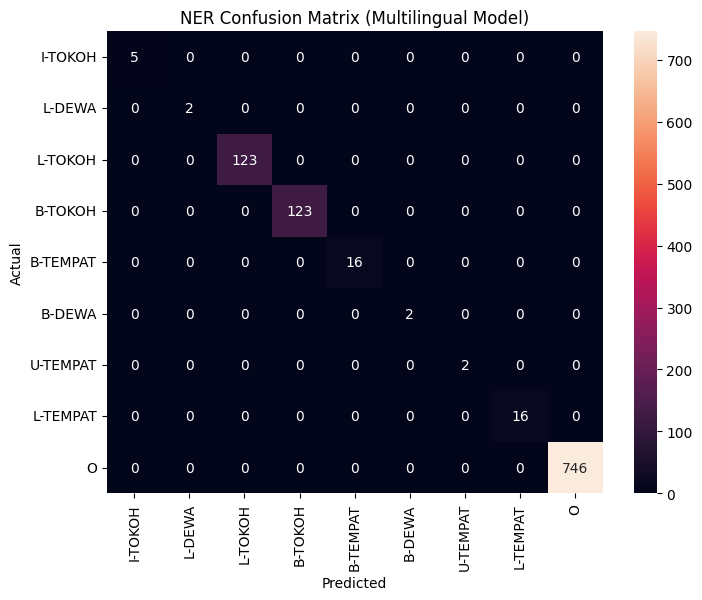

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use the BILUO tags which are guaranteed to have consistent lengths
labels_set = list(set(y_true_biluo_tags_multi + y_pred_biluo_tags_multi))
cm = confusion_matrix(y_true_biluo_tags_multi, y_pred_biluo_tags_multi, labels=labels_set)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=labels_set, yticklabels=labels_set)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("NER Confusion Matrix (Multilingual Model)")
plt.show()


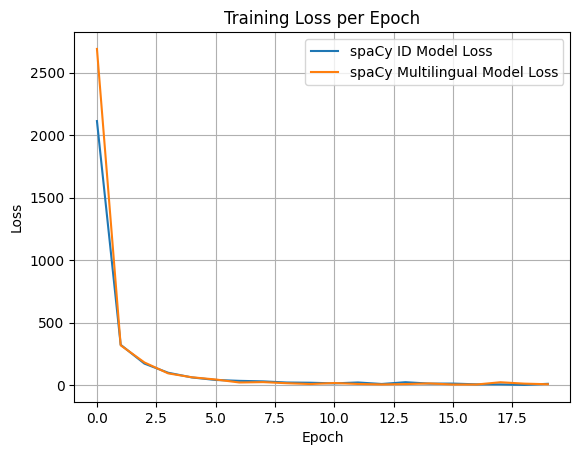

In [54]:
plt.plot(loss_history_id, label="spaCy ID Model Loss")
plt.plot(loss_history_multi, label="spaCy Multilingual Model Loss")
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# prediction

In [88]:
input_text = "Kisah ini menceritakan tentang perjalanan Raden Sitija dan Dewi Sitisundari"
# Apply the same cleaning function used for training data
cleaned_input_text = clean_and_lowercase_text(input_text)

print("=== Predictions from spaCy ID Model (Corrected Text Processing) ===")
doc_id = nlp(cleaned_input_text)
for ent in doc_id.ents:
    print(f"- Entity: {ent.text}, Label: {ent.label_}, Start: {ent.start_char}, End: {ent.end_char}")

print("\n=== Predictions from spaCy Multilingual Model (Corrected Text Processing) ===")
doc_multi = nlp_multi(cleaned_input_text)
for ent in doc_multi.ents:
    print(f"- Entity: {ent.text}, Label: {ent.label_}, Start: {ent.start_char}, End: {ent.end_char}")

=== Predictions from spaCy ID Model (Corrected Text Processing) ===
- Entity: raden sitija, Label: TOKOH, Start: 42, End: 54
- Entity: dewi sitisundari, Label: TOKOH, Start: 59, End: 75

=== Predictions from spaCy Multilingual Model (Corrected Text Processing) ===
- Entity: raden sitija, Label: TOKOH, Start: 42, End: 54
- Entity: dewi sitisundari, Label: TOKOH, Start: 59, End: 75


In [89]:
predicted_entities = doc_id.ents
print(predicted_entities)

(raden sitija, dewi sitisundari)


In [90]:
predicted_entity_texts = {ent.text for ent in predicted_entities}

filtered_sentences = []
for entry in preprocessed_data_from_txt:
    sentence_text = entry["text"]
    # Check if any of the predicted entity texts are present in the sentence
    if any(entity_text in sentence_text for entity_text in predicted_entity_texts):
        filtered_sentences.append(sentence_text)

combined_text = " ".join(filtered_sentences)

print(f"Combined Texth lenght (after filter): {len(combined_text)} karakter")
print("Some first character from combined text (after filter):")
print(combined_text[:500])


Combined Texth lenght (after filter): 15019 karakter
Some first character from combined text (after filter):
raden sitija meminta izin ingin bertemu ayahnya di kahyangan ekapratala batara nagaraja ekawarna dihadap putrinya yaitu batari pretiwi serta kedua cucunya yaitu raden sitija dan dewi sitisundari karena didesak terusmenerus batari pretiwi akhirnya menceritakan bahwa ayah kandung raden sitija dan dewi sitisundari adalah batara wisnu dari kahyangan utarasagara raden sitija sudah bertekad bulat ingin menemui ayahnya maka ia pun mohon pamit kepada sang kakek dan juga ibu untuk pergi ke kerajaan dwara


In [91]:
import json
import google.generativeai as genai
from itertools import combinations

# Get your own gemini key from google ai studio.
genai.configure(api_key="Your API Key")
gemini_model = genai.GenerativeModel('gemini-2.5-flash-lite')
print("Gemini model configured and initialized for relation extraction.")

def generate_kg_from_combined_text_entities(combined_text_input, nlp_model):
    """
    Extracts entities from combined_text_input using the provided nlp_model,
    then uses Gemini to find relationships between these entities.

    combined_text_input: str, the text from which to extract entities and relations.
    nlp_model: a trained spaCy NER model to extract entities.
    """

    # 1. Extract all entities from the combined_text_input using the nlp model
    doc = nlp_model(combined_text_input)
    all_extracted_entities = doc.ents

    # Convert spacy.tokens.Span objects into a list of dictionaries
    # for easier processing and to match prompt structure.
    processed_entities = []
    seen_entities = set() # To track unique (text, label) pairs

    for ent in all_extracted_entities:
        entity_key = (ent.text, ent.label_)
        if entity_key not in seen_entities:
            processed_entities.append({"text": ent.text, "label": ent.label_})
            seen_entities.add(entity_key)

    # Format all entities for the single prompt
    formatted_all_entities_for_prompt = "\n".join(
        [f"- \"{entity['text']}\" (Type: {entity['label']})" for entity in processed_entities]
    )

    # Construct a single, comprehensive prompt to ask Gemini for all relations
    prompt = f"""
    You are an expert in knowledge graph extraction. Your task is to identify and extract
    relationships between the given entities within the provided text.
    The extracted relationships should form a knowledge graph represented as (subject, predicate, object) triples.

    Consider the full knowledge base provided:
    {combined_text_input}

    Here is a list of all identified entities and their types that you should consider for relationship extraction:
    {formatted_all_entities_for_prompt}

    Based on this knowledge and the listed entities, identify ALL direct or implicit relationships that exist
    between any two or more of these entities. Focus ONLY on family, allied, or enemy relationships.
    its important!! do not include any other relationship exept family, allied or enemy relationship.
    Each relationship should be on a new line, following this exact format:
    subject --predicate--> object

    Example:
    Raden Sitija --anak dari--> Batari Pretiwi
    Batari Pretiwi --istri dari--> Batara Wisnu
    If no relationships (ONLY on family, allied, or enemy relationships) are found, output an empty string.
    Do not include any other text or formatting besides the relationship lines.
    """

    triples = []
    response_text = ""
    try:
        response = gemini_model.generate_content(prompt)
        response_text = response.text.strip()

        lines = response_text.split('\n')
        for line in lines:
            line = line.strip()
            if ' --' in line and '-->' in line:
                try:
                    # Find the first occurrence of ' --' and '-->' to split parts
                    idx_start_pred = line.find(' --')
                    idx_end_pred = line.find('-->')

                    if idx_start_pred != -1 and idx_end_pred != -1 and idx_start_pred < idx_end_pred:
                        subject = line[:idx_start_pred].strip()
                        # Extract predicate including '-->' symbol
                        predicate = line[idx_start_pred + 1 : idx_end_pred + 3].strip() # ' --' + predicate + '-->' or just '-->' if no predicate text
                        object = line[idx_end_pred + 3:].strip()

                        # Further refine predicate if it contains ' --' before '-->' to get just the text and then the arrow
                        if predicate.startswith('--'):
                            predicate_text_only = predicate[2:].strip() # Remove leading ' --'
                            if predicate_text_only.endswith('-->'):
                                predicate_text_only = predicate_text_only[:-3].strip() # Remove trailing '-->'
                            predicate = f"--{predicate_text_only}-->"
                        else:
                             # Fallback for unexpected predicate format, ensure it always contains --> if desired
                             if not predicate.endswith('-->'):
                                 predicate = predicate + '-->'

                        if subject and predicate and object:  # Ensure all parts are non-empty
                            triples.append((subject, predicate, object))
                    else:
                        print(f"Warning: Gemini's response line did not match expected format for delimiters: '{line}'. Skipping.")
                except Exception as parse_e:
                    print(f"Warning: Could not parse line '{line}' from Gemini response: {parse_e}. Skipping.")
            elif line:  # If line is not empty and didn't match the format, print a warning
                print(f"Warning: Gemini's response line did not match expected format: '{line}'. Skipping.")

    except Exception as e:
        # Ensure response_text is available if an exception occurs before it's assigned
        print(f"An unexpected error occurred: {e}. Response: {response_text}. Skipping.")

    return triples

# The `predicted_entities` variable from previous cell `BskQVHRvhMmE` is `doc_id.ents`
# We pass `predicted_entities` directly to the function.
kg = generate_kg_from_combined_text_entities(combined_text, nlp_multi)
print("\n=== Knowledge Graph ===")
if kg:
    for triple in kg:
        print(triple)
else:
    print("No knowledge graph triples extracted.")

Gemini model configured and initialized for relation extraction.

=== Knowledge Graph ===
('Raden Sitija', '--anak dari-->', 'Batara Wisnu')
('Dewi Sitisundari', '--anak dari-->', 'Batara Wisnu')
('Raden Sitija', '--saudara dari-->', 'Dewi Sitisundari')
('Dewi Sitisundari', '--saudara dari-->', 'Raden Sitija')
('Batara Nagaraja Ekawarna', '--kakek dari-->', 'Raden Sitija')
('Batara Nagaraja Ekawarna', '--kakek dari-->', 'Dewi Sitisundari')
('Batari Pretiwi', '--ibu dari-->', 'Raden Sitija')
('Batari Pretiwi', '--ibu dari-->', 'Dewi Sitisundari')
('Raden Sitija', '--ingin bertemu-->', 'Batara Wisnu')
('Dewi Sitisundari', '--ingin bertemu-->', 'Batara Wisnu')
('Raden Sitija', '--meminta izin dari-->', 'Batara Ekawarna')
('Dewi Sitisundari', '--meminta izin dari-->', 'Batara Ekawarna')
('Raden Sitija', '--musuh dari-->', 'Prabu Narakasura')
('Dewi Sitisundari', '--musuh dari-->', 'Prabu Narakasura')
('Arya Setyaki', '--sekutu dari-->', 'Raden Sitija')
('Arya Setyaki', '--sekutu dari-->', 

In [59]:
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.1 MB/s eta 0:00:00


In [92]:
from pyvis.network import Network
import os

# Create a pyvis network object
# enabled buttons for physics, navigation etc.
net = Network(notebook=True, height="750px", width="100%", cdn_resources='remote', directed=True)
net.toggle_physics(True)

node_colors_map = {
    'TOKOH': 'skyblue',
    'DEWA': 'lightcoral',
    'TEMPAT': 'lightgreen',
    'PUSAKA': 'gold',
    'default': 'lightgray' # Fallback color for any unclassified entities
}

# Function to get entity label for coloring/grouping in pyvis
def get_entity_label_from_grouped_entities(entity_text, grouped_entities_dict):
    # Clean and lowercase the entity_text to match the format in grouped_entities
    cleaned_entity_text = clean_and_lowercase_text(entity_text)
    for label, entities_list in grouped_entities_dict.items():
        if cleaned_entity_text in entities_list:
            return label
    return "default" # Fallback if not found

# Add nodes and edges from the extracted knowledge graph (kg)
# Use a set to keep track of added nodes to prevent duplicates
added_nodes = set()

for subject, predicate, object_node in kg:
    # Determine subject and object labels for styling
    subject_label = get_entity_label_from_grouped_entities(subject, grouped_entities)
    object_label = get_entity_label_from_grouped_entities(object_node, grouped_entities)

    # Add subject node if not already added
    if subject not in added_nodes:
        color = node_colors_map.get(subject_label, node_colors_map['default'])
        # Set node label font color to black
        net.add_node(subject, label=subject, color=color, title=f"Type: {subject_label}", font={'color': 'black'})
        added_nodes.add(subject)

    # Add object node if not already added
    if object_node not in added_nodes:
        color = node_colors_map.get(object_label, node_colors_map['default'])
        # Set node label font color to black
        net.add_node(object_node, label=object_node, color=color, title=f"Type: {object_label}", font={'color': 'black'})
        added_nodes.add(object_node)

    # Add edge
    # Remove '--' and '-->' from predicate for cleaner display
    clean_predicate = predicate.replace('--', '').replace('>', '').strip()
    # Set edge label font color to red
    net.add_edge(subject, object_node, title=clean_predicate, label=clean_predicate, font={'color': 'gray'})

# Save the network to an HTML file
os.makedirs('/content/output', exist_ok=True)
output_filename = '/content/output/interactive_knowledge_graph.html'
net.save_graph(output_filename)

print(f"Interactive knowledge graph saved to {output_filename}")
print("To view the interactive graph, open the HTML file in your web browser.")

# Display the graph in the notebook (if notebook=True is set)
# This is implicitly handled by net.save_graph() when notebook=True

Interactive knowledge graph saved to /content/output/interactive_knowledge_graph.html
To view the interactive graph, open the HTML file in your web browser.


Cosine Similarity

In [93]:
print("\n--- Sample of Extracted Knowledge Graph Triples for Manual Evaluation ---")
for i, triple in enumerate(kg):
    if i >= 10:
        break
    print(f"Triple {i+1}: {triple[0]} {triple[1]} {triple[2]}")

print("\nThis sample is for manual evaluation of the extracted relationships.")
print("A comprehensive quantitative evaluation would require a ground truth dataset with annotated relationships.")


--- Sample of Extracted Knowledge Graph Triples for Manual Evaluation ---
Triple 1: Raden Sitija --anak dari--> Batara Wisnu
Triple 2: Dewi Sitisundari --anak dari--> Batara Wisnu
Triple 3: Raden Sitija --saudara dari--> Dewi Sitisundari
Triple 4: Dewi Sitisundari --saudara dari--> Raden Sitija
Triple 5: Batara Nagaraja Ekawarna --kakek dari--> Raden Sitija
Triple 6: Batara Nagaraja Ekawarna --kakek dari--> Dewi Sitisundari
Triple 7: Batari Pretiwi --ibu dari--> Raden Sitija
Triple 8: Batari Pretiwi --ibu dari--> Dewi Sitisundari
Triple 9: Raden Sitija --ingin bertemu--> Batara Wisnu
Triple 10: Dewi Sitisundari --ingin bertemu--> Batara Wisnu

This sample is for manual evaluation of the extracted relationships.
A comprehensive quantitative evaluation would require a ground truth dataset with annotated relationships.


In [94]:
unique_entities = set()
for subject, _, object_node in kg:
    unique_entities.add(subject)
    unique_entities.add(object_node)

print(f"Total unique entities identified: {len(unique_entities)}")
print("First 10 unique entities:")
for i, entity in enumerate(list(unique_entities)):
    if i >= 10:
        break
    print(f"- {entity}")

Total unique entities identified: 40
First 10 unique entities:
- Arya Dursasana
- Paksi Wilmuna
- Raden Sitija
- Raden Gatutkaca
- Patih Sangkuni
- Patih Surata
- Dewi Banuwati
- Kerajaan Surateleng
- Batara Indra
- Raden Lesmana Mandrakumara


In [95]:
# Download a spaCy model that includes word vectors (using en_core_web_lg as a fallback since xx_ent_wiki_lg failed)
!python -m spacy download en_core_web_lg

# Reload the nlp_multi model with the new, larger model
nlp_vector = spacy.load("en_core_web_lg")

# Add NER if not already present in the new nlp_vector pipeline
if "ner" not in nlp_vector.pipe_names:
    ner = nlp_vector.add_pipe("ner")
else:
    ner = nlp_vector.get_pipe("ner")

# Re-add the custom labels to the NER pipeline
labels = ["TOKOH", "DEWA", "TEMPAT", "PUSAKA"]
for label in labels:
    if label not in ner.labels:
        ner.add_label(label)

print("nlp_vector re-initialized with the selected model, including NER component and custom labels.")

# Verify if the re-loaded model has vectors
test_doc = nlp_vector("test text")
if test_doc.has_vector:
    print("SUCCESS: The nlp_multi model now has vectors available.")
else:
    print("WARNING: The nlp_multi model still does NOT have vectors available. Embedding generation will be incomplete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 1.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
nlp_vector re-initialized with the selected model, including NER component and custom labels.
SUCCESS: The nlp_multi model now has vectors available.


In [96]:
import numpy as np

entity_embeddings = {}
for entity_text in unique_entities:
    # Use the nlp_multi model to get the vector for each entity
    doc = nlp_vector(entity_text)
    if doc.has_vector:
        entity_embeddings[entity_text] = doc.vector
    else:
        print(f"Warning: Entity '{entity_text}' does not have a vector after re-initialization. Skipping.")

print(f"Generated embeddings for {len(entity_embeddings)} unique entities.")
print("Example embedding (first 5 values for a random entity):")
if entity_embeddings:
    random_entity = list(entity_embeddings.keys())[0]
    print(f"Entity: {random_entity}, Embedding[:5]: {entity_embeddings[random_entity][:5]}")

Generated embeddings for 14 unique entities.
Example embedding (first 5 values for a random entity):
Entity: Arya Dursasana, Embedding[:5]: [0.14916  0.087355 0.035296 0.255225 0.11989 ]


In [97]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Filter out entities that didn't get embeddings
valid_entities = list(entity_embeddings.keys())
valid_embeddings = np.array(list(entity_embeddings.values()))

if len(valid_entities) < 2:
    print("Warning: Not enough entities with embeddings to calculate similarity matrix. Need at least 2.")
    similarity_matrix_df = pd.DataFrame()
else:
    # Calculate cosine similarity between all pairs of embeddings
    similarity_matrix = cosine_similarity(valid_embeddings)

    # Create a DataFrame for better visualization
    similarity_matrix_df = pd.DataFrame(
        similarity_matrix,
        index=valid_entities,
        columns=valid_entities
    )

    print("Cosine similarity matrix calculated.")
    print("Shape of similarity matrix:", similarity_matrix_df.shape)
    print("First 5 rows of the similarity matrix:")
    print(similarity_matrix_df.head())


Cosine similarity matrix calculated.
Shape of similarity matrix: (14, 14)
First 5 rows of the similarity matrix:
                 Arya Dursasana  Raden Sitija  Raden Gatutkaca  Dewi Banuwati  \
Arya Dursasana         1.000000      0.283323         0.283323       0.385940   
Raden Sitija           0.283323      1.000000         1.000000       0.383653   
Raden Gatutkaca        0.283323      1.000000         1.000000       0.383653   
Dewi Banuwati          0.385940      0.383653         0.383653       1.000000   
Batara Indra           0.421727      0.370425         0.370425       0.457263   

                 Batara Indra  Raden Lesmana Mandrakumara  Arya Setyaki  \
Arya Dursasana       0.421727                    0.283323      1.000000   
Raden Sitija         0.370425                    1.000000      0.283323   
Raden Gatutkaca      0.370425                    1.000000      0.283323   
Dewi Banuwati        0.457263                    0.383652      0.385940   
Batara Indra         1.00

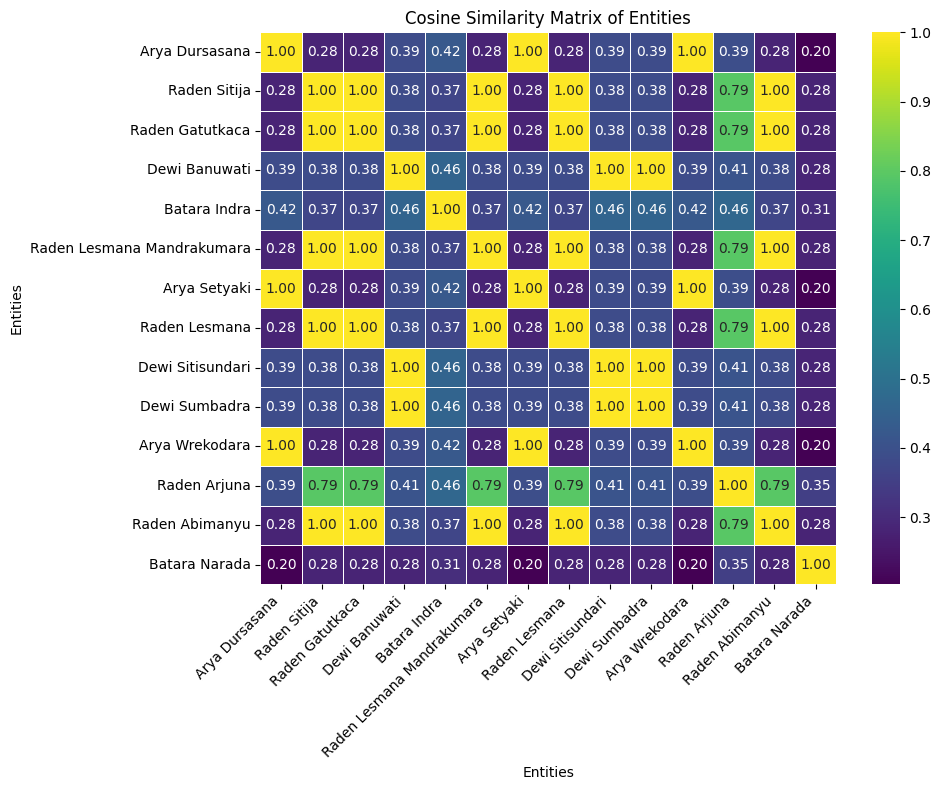

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure similarity_matrix_df is not empty before plotting
if not similarity_matrix_df.empty:
    plt.figure(figsize=(10, 8))
    sns.heatmap(similarity_matrix_df, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
    plt.title('Cosine Similarity Matrix of Entities')
    plt.xlabel('Entities')
    plt.ylabel('Entities')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Similarity matrix is empty, cannot generate heatmap.")